In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
print("Environment ready ")

Environment ready 


dd

In [2]:
okrs = pd.DataFrame([
    {"objective": "Make checkout the fastest in our category",
     "key_result": "Cut checkout time from 90s to 30s",
     "baseline": 90, "current": 52, "target": 30, "unit": "seconds", "lower_is_better": True,
     "owner": "Checkout squad", "quarter": "Q3"},
    {"objective": "Make checkout the fastest in our category",
     "key_result": "Raise checkout conversion rate",
     "baseline": 61, "current": 71, "target": 80, "unit": "%", "lower_is_better": False,
     "owner": "Checkout squad", "quarter": "Q3"},
    {"objective": "Make checkout the fastest in our category",
     "key_result": "Increase repeat-purchase rate",
     "baseline": 22, "current": 27, "target": 35, "unit": "%", "lower_is_better": False,
     "owner": "Growth squad", "quarter": "Q4"},
])

def progress_pct(row):
    span = row.target - row.baseline
    done = row.current - row.baseline
    pct = 0 if span == 0 else (done / span) * 100
    return round(max(0, min(100, pct)), 1)

okrs["progress_pct"] = okrs.apply(progress_pct, axis=1)
okrs

,objective,key_result,baseline,current,target,unit,lower_is_better,owner,quarter,progress_pct
0,Make checkout the fastest in our category,Cut checkout time from 90s to 30s,90,52,30,seconds,True,Checkout squad,Q3,63.3
1,Make checkout the fastest in our category,Raise checkout conversion rate,61,71,80,%,False,Checkout squad,Q3,52.6
2,Make checkout the fastest in our category,Increase repeat-purchase rate,22,27,35,%,False,Growth squad,Q4,38.5


In [4]:
roadmap = pd.DataFrame([
    {"initiative": "One-click checkout",        "key_result": "Cut checkout time from 90s to 30s",
     "start": "2026-07-01", "end": "2026-08-15", "confidence": "High"},
    {"initiative": "Guest checkout (no signup)", "key_result": "Cut checkout time from 90s to 30s",
     "start": "2026-08-01", "end": "2026-09-15", "confidence": "Medium"},
    {"initiative": "Saved-payment autofill",     "key_result": "Raise checkout conversion rate",
     "start": "2026-07-15", "end": "2026-08-30", "confidence": "High"},
    {"initiative": "Trust badges & reviews",     "key_result": "Raise checkout conversion rate",
     "start": "2026-09-01", "end": "2026-09-30", "confidence": "Medium"},
    {"initiative": "Referral program",           "key_result": "Increase repeat-purchase rate",
     "start": "2026-10-01", "end": "2026-11-15", "confidence": "Low"},
    {"initiative": "Post-purchase loyalty tier",  "key_result": "Increase repeat-purchase rate",
     "start": "2026-11-01", "end": "2026-12-15", "confidence": "Medium"},
])
roadmap["start"] = pd.to_datetime(roadmap["start"])
roadmap["end"] = pd.to_datetime(roadmap["end"])
roadmap["duration_days"] = (roadmap["end"] - roadmap["start"]).dt.days
roadmap

,initiative,key_result,start,end,confidence,duration_days
0,One-click checkout,Cut checkout time from 90s to 30s,2026-07-01,2026-08-15,High,45
1,Guest checkout (no signup),Cut checkout time from 90s to 30s,2026-08-01,2026-09-15,Medium,45
2,Saved-payment autofill,Raise checkout conversion rate,2026-07-15,2026-08-30,High,46
3,Trust badges & reviews,Raise checkout conversion rate,2026-09-01,2026-09-30,Medium,29
4,Referral program,Increase repeat-purchase rate,2026-10-01,2026-11-15,Low,45
5,Post-purchase loyalty tier,Increase repeat-purchase rate,2026-11-01,2026-12-15,Medium,44


plot the success

/tmp/ipykernel_655/2159624776.py:15: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_655/2159624776.py:15: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_655/2159624776.py:15: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print

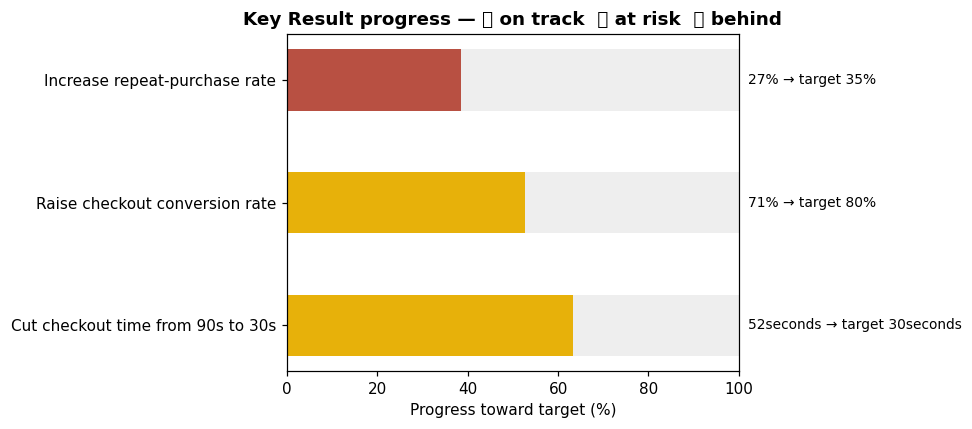

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(okrs))
colors = ["#2C5F2D" if p >= 70 else "#E7B10A" if p >= 40 else "#B85042" for p in okrs.progress_pct]

ax.barh(y_pos, okrs.progress_pct, color=colors, height=0.5)
ax.barh(y_pos, 100, color="#EEEEEE", height=0.5, zorder=0)
ax.barh(y_pos, okrs.progress_pct, color=colors, height=0.5, zorder=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(okrs.key_result)
ax.set_xlim(0, 100)
ax.set_xlabel("Progress toward target (%)")
ax.set_title("Key Result progress — 🟢 on track  🟡 at risk  🔴 behind", fontsize=12, fontweight="bold")
for i, (p, cur, tgt, unit) in enumerate(zip(okrs.progress_pct, okrs.current, okrs.target, okrs.unit)):
    ax.text(102, i, f"{cur}{unit} → target {tgt}{unit}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
roadmap = pd.DataFrame([
    {"initiative": "One-click checkout",        "key_result": "Cut checkout time from 90s to 30s",
     "start": "2026-07-01", "end": "2026-08-15", "confidence": "High"},
    {"initiative": "Guest checkout (no signup)", "key_result": "Cut checkout time from 90s to 30s",
     "start": "2026-08-01", "end": "2026-09-15", "confidence": "Medium"},
    {"initiative": "Saved-payment autofill",     "key_result": "Raise checkout conversion rate",
     "start": "2026-07-15", "end": "2026-08-30", "confidence": "High"},
    {"initiative": "Trust badges & reviews",     "key_result": "Raise checkout conversion rate",
     "start": "2026-09-01", "end": "2026-09-30", "confidence": "Medium"},
    {"initiative": "Referral program",           "key_result": "Increase repeat-purchase rate",
     "start": "2026-10-01", "end": "2026-11-15", "confidence": "Low"},
    {"initiative": "Post-purchase loyalty tier",  "key_result": "Increase repeat-purchase rate",
     "start": "2026-11-01", "end": "2026-12-15", "confidence": "Medium"},
])
roadmap["start"] = pd.to_datetime(roadmap["start"])
roadmap["end"] = pd.to_datetime(roadmap["end"])
roadmap["duration_days"] = (roadmap["end"] - roadmap["start"]).dt.days
roadmap

,initiative,key_result,start,end,confidence,duration_days
0,One-click checkout,Cut checkout time from 90s to 30s,2026-07-01,2026-08-15,High,45
1,Guest checkout (no signup),Cut checkout time from 90s to 30s,2026-08-01,2026-09-15,Medium,45
2,Saved-payment autofill,Raise checkout conversion rate,2026-07-15,2026-08-30,High,46
3,Trust badges & reviews,Raise checkout conversion rate,2026-09-01,2026-09-30,Medium,29
4,Referral program,Increase repeat-purchase rate,2026-10-01,2026-11-15,Low,45
5,Post-purchase loyalty tier,Increase repeat-purchase rate,2026-11-01,2026-12-15,Medium,44


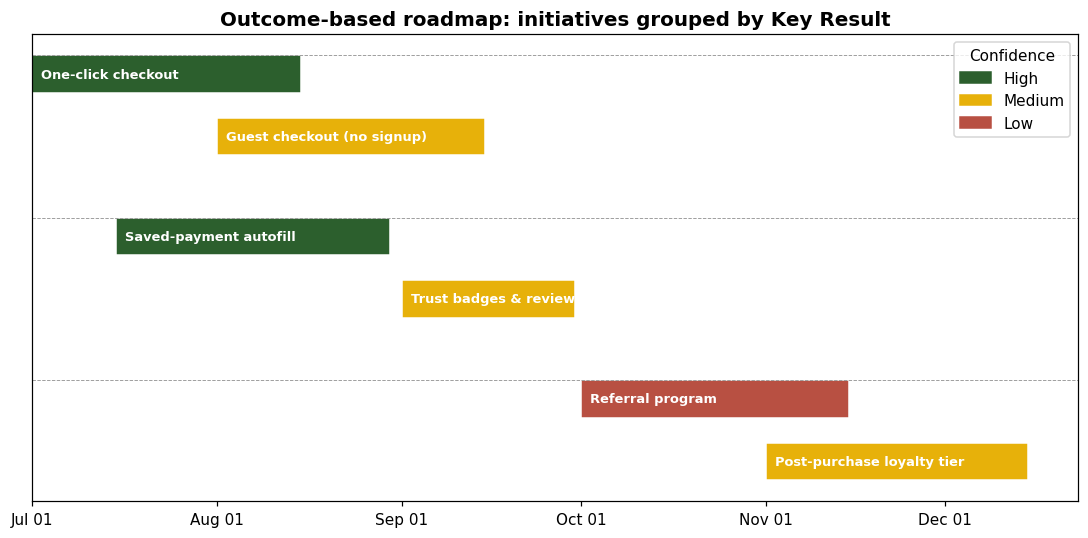

In [6]:
conf_color = {"High": "#2C5F2D", "Medium": "#E7B10A", "Low": "#B85042"}
krs = roadmap["key_result"].unique()
fig, ax = plt.subplots(figsize=(10, 5))

y = 0
yticks, yticklabels = [], []
for kr in krs:
    rows = roadmap[roadmap["key_result"] == kr]
    for _, r in rows.iterrows():
        ax.barh(y, r.duration_days, left=r.start, height=0.6,
                color=conf_color[r.confidence], edgecolor="white")
        ax.text(r.start, y, f"  {r.initiative}", va="center", ha="left",
                fontsize=8.5, color="white", fontweight="bold")
        yticks.append(y); yticklabels.append("")
        y += 1
    y += 0.6

ax.set_yticks([]); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Outcome-based roadmap: initiatives grouped by Key Result", fontsize=13, fontweight="bold")
handles = [plt.Rectangle((0,0),1,1, color=c) for c in conf_color.values()]
ax.legend(handles, conf_color.keys(), title="Confidence", loc="upper right")

# annotate KR group boundaries
running = 0
for kr in krs:
    n = len(roadmap[roadmap["key_result"] == kr])
    ax.axhline(running - 0.3, color="#999999", linewidth=0.6, linestyle="--")
    running += n + 0.6
plt.tight_layout()
plt.show()

In [7]:
# --- Extension Task 1: Add a new Key Result and initiatives
new_kr = {
    "objective": "Improve checkout UX",
    "key_result": "Reduce cart abandonment rate",
    "baseline": 70,
    "current": 60,
    "target": 50,
    "unit": "%",
    "lower_is_better": True,
    "owner": "Checkout squad",
    "quarter": "Q4",
}
# Append the new KR
okrs = pd.concat([okrs, pd.DataFrame([new_kr])], ignore_index=True)
okrs["progress_pct"] = okrs.apply(progress_pct, axis=1)

# Add corresponding initiatives to the roadmap
new_initiatives = [
    {"initiative": "Cart recovery popup", "key_result": "Reduce cart abandonment rate", "start": "2026-08-20", "end": "2026-09-10", "confidence": "High"},
    {"initiative": "Guest checkout optimization", "key_result": "Reduce cart abandonment rate", "start": "2026-09-11", "end": "2026-10-01", "confidence": "Medium"},
]
roadmap = pd.concat([roadmap, pd.DataFrame(new_initiatives)], ignore_index=True)
roadmap["start"] = pd.to_datetime(roadmap["start"])
roadmap["end"] = pd.to_datetime(roadmap["end"])
roadmap["duration_days"] = (roadmap["end"] - roadmap["start"]).dt.days

print("Added new Key Result and initiatives.")
okrs, roadmap

Added new Key Result and initiatives.


(                                   objective  \
 0  Make checkout the fastest in our category   
 1  Make checkout the fastest in our category   
 2  Make checkout the fastest in our category   
 3                        Improve checkout UX   
 
                           key_result  baseline  current  target     unit  \
 0  Cut checkout time from 90s to 30s        90       52      30  seconds   
 1     Raise checkout conversion rate        61       71      80        %   
 2      Increase repeat-purchase rate        22       27      35        %   
 3       Reduce cart abandonment rate        70       60      50        %   
 
    lower_is_better           owner quarter  progress_pct  
 0             True  Checkout squad      Q3          63.3  
 1            False  Checkout squad      Q3          52.6  
 2            False    Growth squad      Q4          38.5  
 3             True  Checkout squad      Q4          50.0  ,
                     initiative                         key_resul

In [9]:
# --- Extension Task 2: Confidence filter (interactive if ipywidgets available)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    has_widgets = True
except Exception:
    has_widgets = False

# Predefine widget placeholders so update_plot can reference them safely
out = None
filter_widget = None

def plot_roadmap(filtered_roadmap):
    import matplotlib.dates as mdates
    fig, ax = plt.subplots(figsize=(10, 5))
    conf_color = {"High": "#2C5F2D", "Medium": "#E7B10A", "Low": "#B85042"}
    krs = filtered_roadmap["key_result"].unique()
    y = 0
    for kr in krs:
        rows = filtered_roadmap[filtered_roadmap["key_result"] == kr]
        for _, r in rows.iterrows():
            ax.barh(y, r.duration_days, left=r.start, height=0.6,
                    color=conf_color.get(r.confidence, "#888888"), edgecolor="white")
            ax.text(r.start, y, f"  {r.initiative}", va="center", ha="left",
                    fontsize=8.5, color="white", fontweight="bold")
            y += 1
        y += 0.6

    ax.set_yticks([]); ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.set_title("Outcome-based roadmap: initiatives grouped by Key Result", fontsize=13, fontweight="bold")
    handles = [plt.Rectangle((0,0),1,1, color=c) for c in conf_color.values()]
    ax.legend(handles, conf_color.keys(), title="Confidence", loc="upper right")
    plt.tight_layout()
    plt.show()


def update_plot(confidence):
    if confidence == "All":
        filtered = roadmap.copy()
    else:
        filtered = roadmap[roadmap["confidence"] == confidence]
    filtered = filtered.copy()
    filtered["start"] = pd.to_datetime(filtered["start"])
    filtered["end"] = pd.to_datetime(filtered["end"])
    filtered["duration_days"] = (filtered["end"] - filtered["start"]).dt.days
    if has_widgets and filter_widget is not None and out is not None:
        clear_output(wait=True)
        display(filter_widget, out)
    plot_roadmap(filtered)

if has_widgets:
    options = ["All"] + sorted(roadmap["confidence"].dropna().unique().tolist())
    filter_widget = widgets.Dropdown(options=options, value="All", description="Confidence:")
    out = widgets.interactive_output(update_plot, {"confidence": filter_widget})
    display(filter_widget, out)
else:
    print("ipywidgets not available — showing full roadmap (non-interactive)")
    plot_roadmap(roadmap)

Dropdown(description='Confidence:', options=('All', 'High', 'Low', 'Medium'), value='All')

Output()